In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def plot_phase_portrait(f, x_range, y_range, sys_num, initial_conditions, equilibria=(), equilibrium_curves=(), density=30):
    x = np.linspace(x_range[0], x_range[1], density)
    y = np.linspace(y_range[0], y_range[1], density)
    X, Y = np.meshgrid(x, y)

    U, V = f(X, Y)

    def plot_trajectories(f, initial_conditions, t_span=(0, 10), dt=0.01):
        for x0, y0 in initial_conditions:
            trajectory = np.array([[x0, y0]])
            t = 0
            while t < t_span[1]:
                dx, dy = f(trajectory[-1, 0], trajectory[-1, 1])
                trajectory = np.vstack([trajectory, trajectory[-1] + dt * np.array([dx, dy])])
                t += dt
            plt.plot(trajectory[:, 0], trajectory[:, 1], lw=2, alpha=1)

    plt.figure(figsize=(10, 8))
    M = np.sqrt(U**2 + V**2) / (x_range[1] - x_range[0]) * 40

    U_norm = np.divide(U, M, out=np.zeros_like(U), where=M != 0)
    V_norm = np.divide(V, M, out=np.zeros_like(V), where=M != 0)

    q = plt.quiver(
        X, Y,
        U_norm, V_norm,
        M,
        cmap='viridis',
        angles='xy',
        scale_units='xy',
        scale=1
    )
    plot_trajectories(f, initial_conditions)

    if equilibria:
        equilibria_array = np.asarray(equilibria, dtype=float)
        plt.scatter(
            equilibria_array[:, 0], equilibria_array[:, 1],
            s=100, marker='.', color='red', edgecolors='black',
            linewidths=0.8, zorder=5
        )

    for curve in equilibrium_curves:
        curve = np.asarray(curve, dtype=float)
        plt.plot(curve[:, 0], curve[:, 1], color='red', linewidth=2, zorder=5)
    plt.xlim(x_range)
    plt.ylim(y_range)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'System {sys_num} Phase Portrait')
    plt.grid()
    plt.savefig(f'../tex/images/phase_portrait_{sys_num}.png', dpi=300)

sys1 = lambda x1, x2: (-x1+2*x1**3+x2, -x1-x2)
sys2 = lambda x1, x2: (x1+x1*x2, -x2+x2**2+x1*x2-x1**3)
sys3 = lambda x1, x2: (x2, -x1+x2*(1-x1**2+0.1*x1**4))
sys4 = lambda x1, x2: ((x1-x2)*(1-x1**2-x2**2), (x1+x2)*(1-x1**2-x2**2))
sys5 = lambda x1, x2: (-x1**3+x2, x1-x2**3)
sys6 = lambda x1, x2: (-x1**3+x2**3, x2**3*x1-x2**3)

C:\Users\Nickolay\AppData\Local\Temp\ipykernel_8080\1968713199.py:55: RuntimeWarning: overflow encountered in scalar multiply
  sys2 = lambda x1, x2: (x1+x1*x2, -x2+x2**2+x1*x2-x1**3)
C:\Users\Nickolay\AppData\Local\Temp\ipykernel_8080\1968713199.py:55: RuntimeWarning: overflow encountered in scalar power
  sys2 = lambda x1, x2: (x1+x1*x2, -x2+x2**2+x1*x2-x1**3)
C:\Users\Nickolay\AppData\Local\Temp\ipykernel_8080\1968713199.py:55: RuntimeWarning: invalid value encountered in scalar add
  sys2 = lambda x1, x2: (x1+x1*x2, -x2+x2**2+x1*x2-x1**3)
C:\Users\Nickolay\AppData\Local\Temp\ipykernel_8080\1968713199.py:59: RuntimeWarning: overflow encountered in scalar power
  sys6 = lambda x1, x2: (-x1**3+x2**3, x2**3*x1-x2**3)
C:\Users\Nickolay\AppData\Local\Temp\ipykernel_8080\1968713199.py:59: RuntimeWarning: invalid value encountered in scalar add
  sys6 = lambda x1, x2: (-x1**3+x2**3, x2**3*x1-x2**3)
C:\Users\Nickolay\AppData\Local\Temp\ipykernel_8080\1968713199.py:59: RuntimeWarning: invali

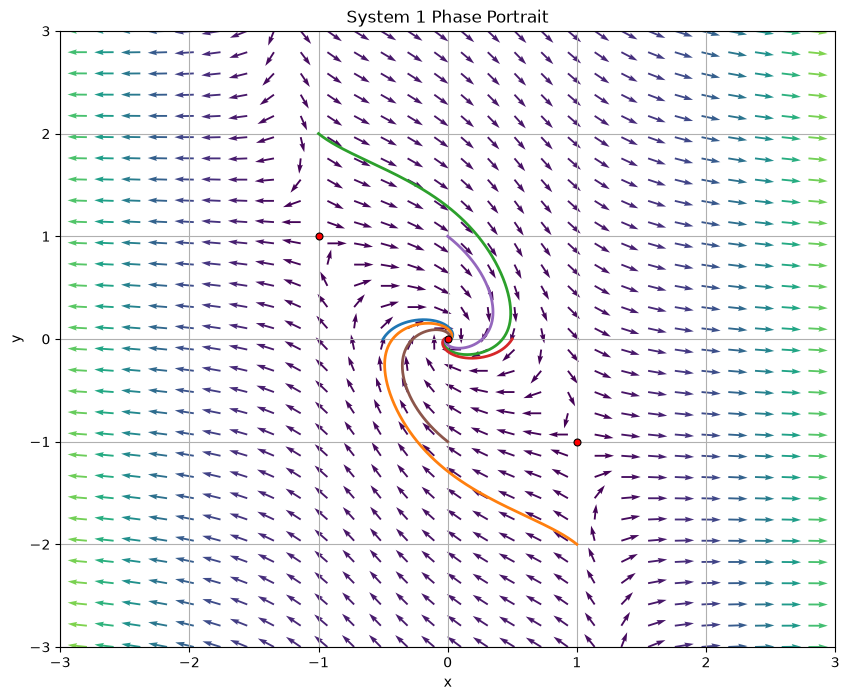

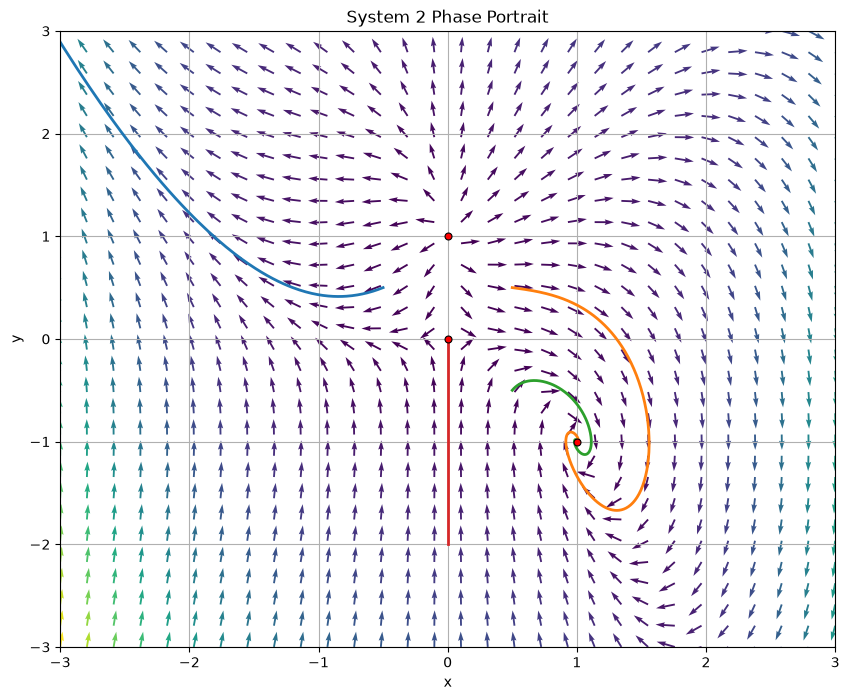

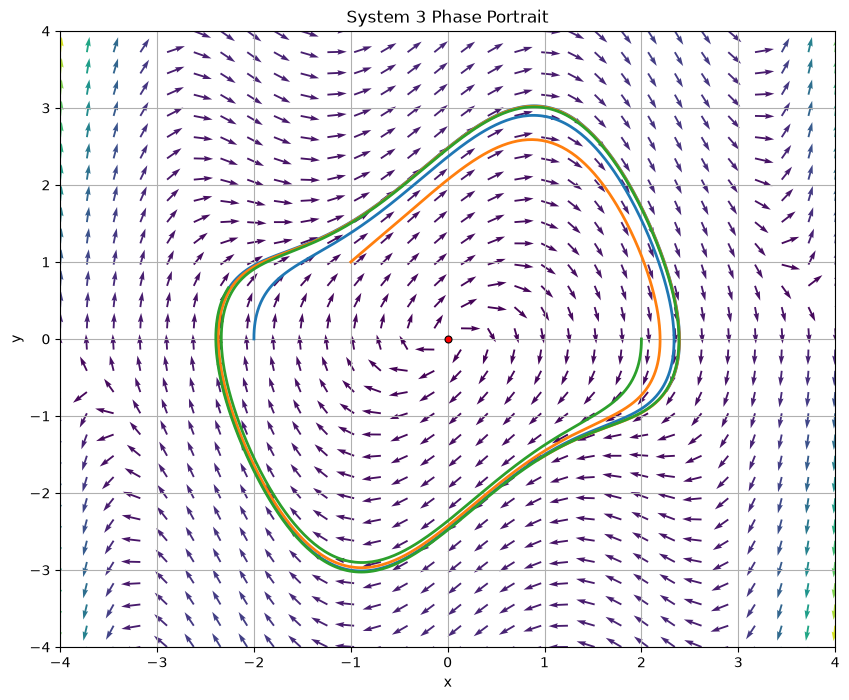

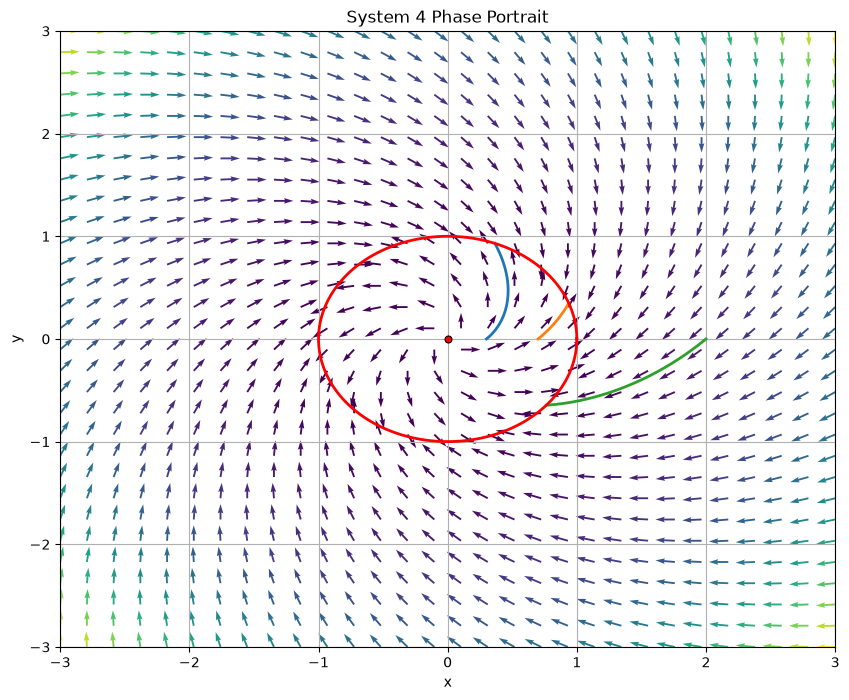

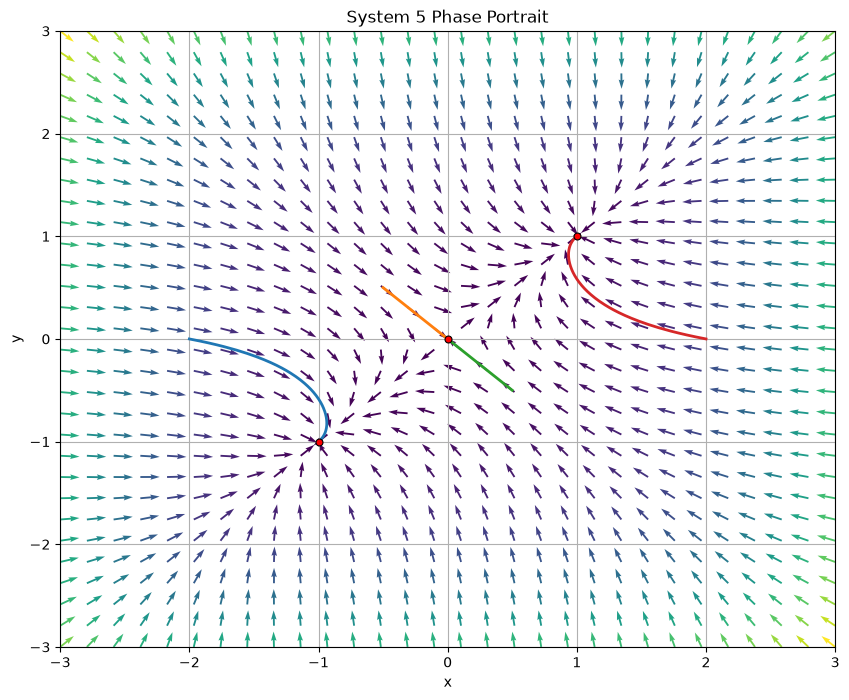

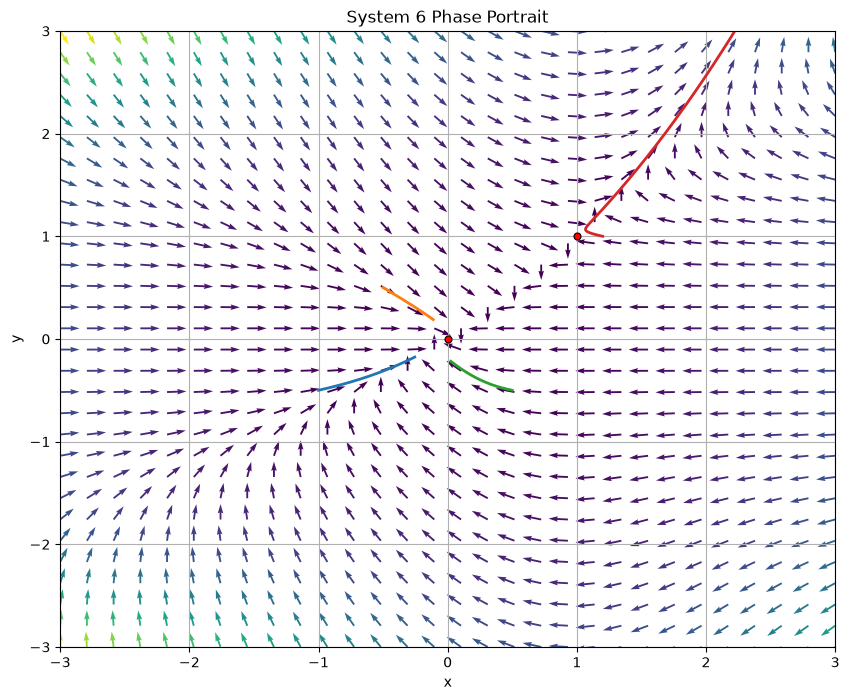

In [11]:
initial_conditions_1 = [(-0.5, 0.0), (1, -2), (-1, 2), (0.5, 0.0), (0.0, 1.0), (0.0, -1.0)]
initial_conditions_2 = [(-0.5, 0.5), (0.5, 0.5), (0.5, -0.5), (0, -2.0)]
initial_conditions_3 = [(-2.0, 0.0), (-1.0, 1.0),(2.0, 0.0)]
initial_conditions_4 = [(0.3, 0.0), (0.7, 0.0), (2.0, 0.0)]
initial_conditions_5 = [(-2.0, 0.0), (-0.5, 0.5), (0.5, -0.5), (2.0, 0.0)]
initial_conditions_6 = [(-1.0, -0.5), (-0.5, 0.5), (0.5, -0.5), (1.2, 1.0)]

phi = np.linspace(0, 2 * np.pi, 400)
circle_4 = np.column_stack((np.cos(phi), np.sin(phi)))

plot_phase_portrait(sys1, (-3, 3), (-3, 3), "1", initial_conditions_1, equilibria=[(0, 0), (1, -1), (-1, 1)])
plot_phase_portrait(sys2, (-3, 3), (-3, 3), "2", initial_conditions_2, equilibria=[(0, 0), (0, 1), (1, -1)])
plot_phase_portrait(sys3, (-4, 4), (-4, 4), "3", initial_conditions_3, equilibria=[(0, 0)])
plot_phase_portrait(sys4, (-3, 3), (-3, 3), "4", initial_conditions_4, equilibria=[(0, 0)], equilibrium_curves=[circle_4])
plot_phase_portrait(sys5, (-3, 3), (-3, 3), "5", initial_conditions_5, equilibria=[(0, 0), (1, 1), (-1, -1)])
plot_phase_portrait(sys6, (-3, 3), (-3, 3), "6", initial_conditions_6, equilibria=[(0, 0), (1, 1)])